corresponding to archive-46

In [1]:
import pickle
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import math

seed:0,b::6, v0[i]:0.7145146659246332, v1[i]:0.4871649324011401
seed:0,b::7, v0[i]:0.671740112805884, v1[i]:0.47958812740571666
seed:0,b::8, v0[i]:0.9442367305266547, v1[i]:0.6990080801920062
seed:0,b::9, v0[i]:0.9958259255711095, v1[i]:0.7389689168778188
seed:0,b::10, v0[i]:0.9503679081877654, v1[i]:0.7226850046140006
seed:0,b::11, v0[i]:0.9791856246623546, v1[i]:0.7381236411806142
seed:0,b::12, v0[i]:0.9389544247781849, v1[i]:0.7182248476371202
seed:0,b::13, v0[i]:0.9692697335950813, v1[i]:0.7361544225214857
seed:0,b::14, v0[i]:0.9667898704051824, v1[i]:0.7366016255210953
seed:0,b::15, v0[i]:0.9648309972472271, v1[i]:0.740886381120225
seed:0,b::16, v0[i]:0.9634307952690053, v1[i]:0.7335626149954634
seed:0,b::17, v0[i]:0.963421908723955, v1[i]:0.7419646767920705
seed:0,b::18, v0[i]:0.9359251002560495, v1[i]:0.7319826224649256
seed:0,b::19, v0[i]:0.9367966429409617, v1[i]:0.7253013036445474
seed:0,b::20, v0[i]:0.9385065944019378, v1[i]:0.7261484144053374
seed:0,b::21, v0[i]:0.941530702

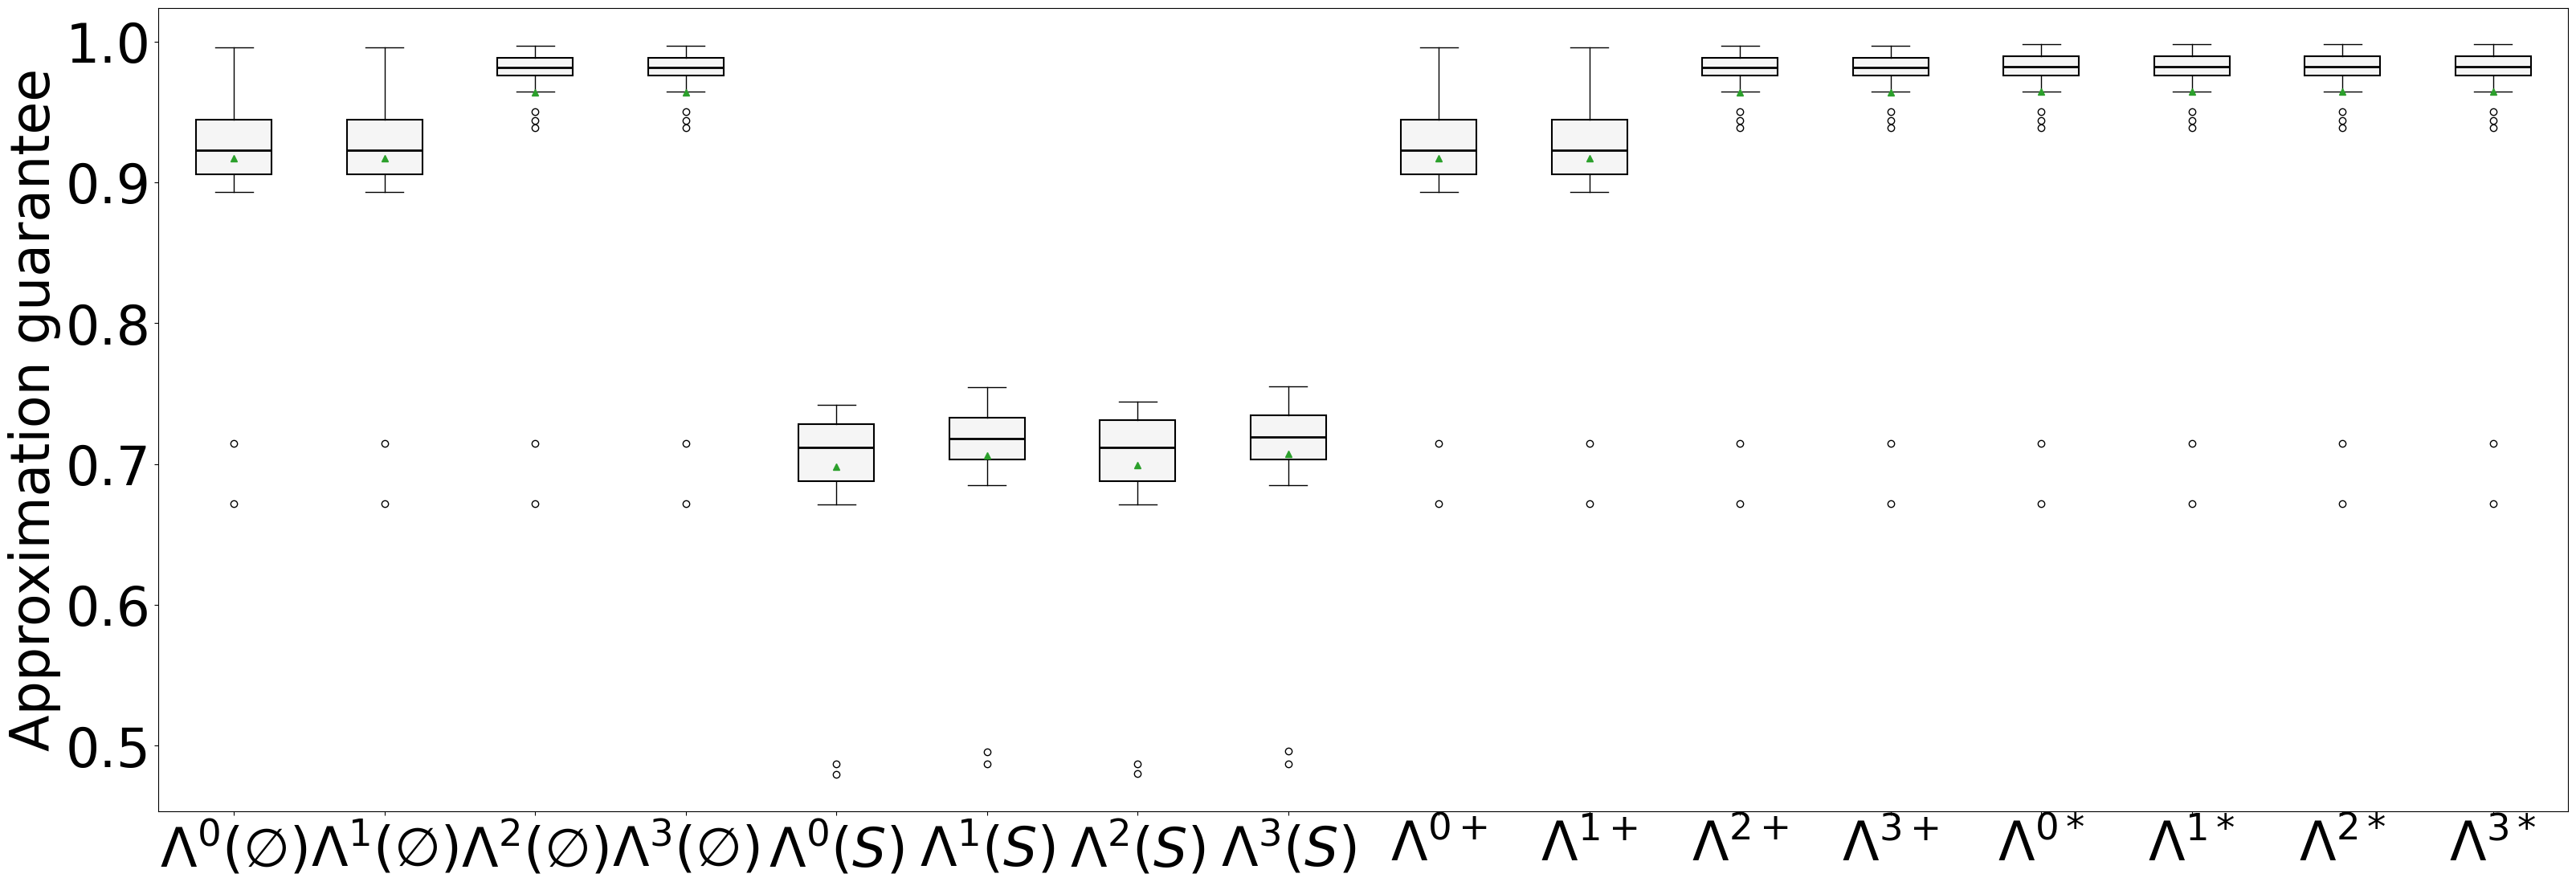

In [ ]:
t = False

def load_12_series(upper_bound: str, task_name: str, source_dir: str):
    """
    kv_data has the following keys: 
    - 'S'
    - 'f(S)'
    - 'c(S)'
    - 'Lambda'
    - 'AF'
    """
    task_dict = {
        "facebook": "FacebookGraphCoverage",
        "youtube" : "YoutubeCoverage",
        "caltech": "CalTechMaximization",
        "adult": "AdultIncomeFeatureSelection"
    }

    res = []
    # print(f"r:{source_dir}")
    for name in os.listdir(source_dir):
        if not os.path.isdir(os.path.join(source_dir, name)):
            algo, up, task, budget = name.strip()[:-5].split('-')
            # print(f"algo:{algo}, up:{up}, upp:{upper_bound}")
            if algo == 'greedy_max'and upper_bound in ['ub1', 'ub1ma', 'ub7', 'ub7ma', 'ub11', 'ub11m', 'ub7u', 'ub7mu'] and up == upper_bound:
                # print("wrong way 0")
                file_path = os.path.join(source_dir, name)
                with open(file_path, "rb") as rd:
                    kv_data = pickle.load(rd)
                # print(kv_data)
                if t:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['Time']))
                else:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['AF']))
            elif algo == 'greedy_max_nis_ept' and upper_bound in ['ub1-', 'ub1ma-', 'ub7-', 'ub7ma-'] and up == upper_bound[:len(upper_bound)-1]:
                # print("wrong way 1")
                file_path = os.path.join(source_dir, name)
                with open(file_path, "rb") as rd:
                    kv_data = pickle.load(rd)
                # print(kv_data)
                if t:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['Time']))
                else:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['AF']))
            elif algo == 'greedy_max_nis_sol' and upper_bound in ['ub1si', 'ub1masi', 'ub7si', 'ub7masi'] and up == upper_bound[:len(upper_bound)-2]:
                file_path = os.path.join(source_dir, name)
                # print(file_path)
                with open(file_path, "rb") as rd:
                    kv_data = pickle.load(rd)
                # print(kv_data)
                if t:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['Time']))
                else:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['AF']))



    res = sorted(res, key=lambda x: x[0])
    # print(res)
    X, Y, Z, W = list(zip(*res))   # change it to two columns
    return X, Y, Z, W

task_list = ['youtube']

ub_list = [
    'ub1-', 'ub1ma-', 'ub7-', 'ub7ma-',
    'ub1si', 'ub1masi', 'ub7si', 'ub7masi',
    'ub1', 'ub1ma', 'ub7', 'ub7ma',
    'ub11', 'ub11m', 'ub7u', 'ub7mu'
]
# ub_list = [
#     'ub7ma-', 'ub7ma'
# ]
# ub_list = [
#     'ub1si', 'ub1masi', 'ub7si', 'ub7masi',
# ]

ub_title_dict = {
    'ub1-': r"$\Lambda^{0}(\emptyset)$",
    'ub1ma-': r"$\Lambda^{1}(\emptyset)$",
    'ub7-': r"$\Lambda^{2}(\emptyset)$",
    'ub7ma-': r"$\Lambda^{3}(\emptyset)$",
    'ub1si': r"$\Lambda^{0}(S)$",
    'ub1masi': r"$\Lambda^{1}(S)$",
    'ub7si': r"$\Lambda^{2}(S)$",
    'ub7masi': r"$\Lambda^{3}(S)$",
    'ub1': r"$\Lambda^{0+}$",
    'ub1ma': r"$\Lambda^{1+}$",
    'ub7': r"$\Lambda^{2+}$",
    'ub7ma': r"$\Lambda^{3+}$",
    'ub11': r"$\Lambda^{0*}$",
    'ub11m': r"$\Lambda^{1*}$",
    'ub7u': r"$\Lambda^{2*}$",
    'ub7mu': r"$\Lambda^{3*}$",
}

ub_title_list = [ub_title_dict[ub] for ub in ub_list]

archive_dir = "../result/archive-58"

result_dir = "./result_test"

n = 1000
worst_case = math.log(n, math.e)
fs = 48

u_data_list = []
v_data_list = []
l_data_list = []
for ub in ub_list:
    u_data_list.append([])
    v_data_list.append([])
    l_data_list.append([])

seed_range = range(0, 1)
b_range = range(6,41)

b_data_list = []
for ub in ub_list:
    temp = []
    for v in b_range:
        temp.append([])
    b_data_list.append(temp)
bti_dict = {}
for i in range(0, len(b_range)):
    b = float(b_range[i])
    bti_dict[b] = i

ub_to_draw_list = [0, 1]

count = 0
total_count = len(task_list) + len(ub_list) * len(task_list)

sc = 0
for task in task_list:
    for seed in seed_range:
        v0 = {}
        v1 = {}
        for ub_idx in range(0, len(ub_list)):
            # print(f"seed:{seed}")
            ub = ub_list[ub_idx]
            source_dir = os.path.join(archive_dir, f"{task}", f"{n}", f"{seed}")
            # print(f"seed:{seed}, ub:{ub_list[ub_idx]}")
            X, Y, Z, W = load_12_series(upper_bound=ub, task_name=task, source_dir=source_dir)

            for x_idx in range(0, len(X)):
                b = X[x_idx]
                if b in b_range:
                    b_list_idx = bti_dict[b]
                    b_data_list[ub_idx][b_list_idx].append(W[x_idx])    
                    u_data_list[ub_idx].append(W[x_idx])
                    v_data_list[ub_idx].append(Y[x_idx])
                    l_data_list[ub_idx].append(Z[x_idx])
                    # if ub == 'ub1si' and Z[x_idx] > 40:
                    #     print(f"seed:{seed}, b:{b}")

                    # if ub_idx == 0:
                    #     v0[b] = W[x_idx]
                    # elif ub_idx == 4:
                    #     v1[b] = W[x_idx]
        
        # for i in b_range:
        #     if v0[i] > v1[i]:
        #         print(f"seed:{seed},b::{i}, v0[i]:{v0[i]}, v1[i]:{v1[i]}")

    print(f"same:{sc}, total:{700}")

    # first plot
    data = u_data_list

    plt.rcParams["font.size"] = fs
    fig = plt.figure(figsize=(30, 10))
    ax = fig.add_axes([0,0,1,1])
    if t:
        ax.set_ylabel("Computational time (s)")
    else:
        ax.set_ylabel("Approximation guarantee")

    box_props = dict(linewidth=1.5, color="black")
    median_props = dict(linewidth=2)

    for ub_idx in range(0, len(ub_list)):
        ub = ub_list[ub_idx]
        print(f"ub:{ub}, mean:{np.mean(data[ub_idx])}, mean v:{np.mean(v_data_list[ub_idx])}, mean l:{np.mean(l_data_list[ub_idx])}")

    bp = ax.boxplot(data, patch_artist=True, showfliers=True, tick_labels=ub_title_list, showmeans=True, boxprops=box_props, medianprops=median_props)
    # plt.axhline(y = worst_case, color = 'r', linestyle = '-') 
    
    ax.plot()

    plt.xticks(fontsize=fs) 

    for median in bp["medians"]:
        median.set_color("black")

    for box in bp["boxes"]:
        box.set_facecolor("whitesmoke")

    suffix=""
    if t:
        suffix="_T"
    else:
        suffix=""

    plt.savefig(os.path.join(result_dir, f"{task}_{n}{suffix}.pdf"), format='pdf', bbox_inches='tight')
    plt.savefig(os.path.join(result_dir, f"{task}_{n}{suffix}.jpg"), format='jpg', bbox_inches='tight')
    count = count + 1
    print(f"count:{count}/{total_count} {task}_{n}{suffix}.pdf completed.")

    # # second plot

    # fig = plt.figure(figsize=(10, 10))

    # ax = fig.add_axes([0,0,1,1])
    # if t:
    #     ax.set_ylabel("Computational time (s)")
    # else:
    #     ax.set_ylabel("Approximation guarantee")


    # box_props = dict(linewidth=1.5, color="black")
    # median_props = dict(linewidth=2)
    # mean_props = {"marker":"^","markerfacecolor":"darkgreen", "markeredgecolor":"darkgreen"}
    # flier_props = {"marker":"o","markerfacecolor":"darkgreen", "markeredgecolor":"black"}
    # flier_props = {"marker":"o","markerfacecolor":"darkgreen", "markeredgecolor":"black"}
    # whisker_props = {"color":"black"}

    # color_list = ["whitesmoke","wheat", 'cornsilk']

    # whisker_color_list = ["dimgray","orange",'cornsilk']
    # cc = 0

    # for i in ub_to_draw_list:
    #     data = b_data_list[i]
    #     ub = ub_list[i]

    #     flier_props["markerfacecolor"] = color_list[cc]
    #     whisker_props["color"] = whisker_color_list[cc]

    #     xtick_labels = []
    #     for b in b_range:
    #         if int(b) % 5 == 1:
    #             xtick_labels.append(b)
    #         else:
    #             xtick_labels.append(" ")

    #     bp = ax.boxplot(data,label=ub_title_dict[ub], patch_artist=True, tick_labels=xtick_labels, showmeans=True, boxprops=box_props, medianprops=median_props
    #                     , meanprops=mean_props, flierprops=flier_props, whiskerprops=whisker_props, capprops=whisker_props)
    #     # plt.axhline(y = worst_case, color = 'r', linestyle = '-') 

    #     for median in bp["medians"]:
    #         median.set_color("black")
    #     for box in bp["boxes"]:
    #         box.set_facecolor(color_list[cc])

    #     cc = cc + 1

    #     plt.legend()

    #     plt.savefig(os.path.join(result_dir, f"{task}_{n}_v{suffix}_{ub_to_draw_list[0]}_{ub_to_draw_list[1]}.jpg"), format='jpg', bbox_inches='tight')
    #     plt.savefig(os.path.join(result_dir, f"{task}_{n}_v{suffix}_{ub_to_draw_list[0]}_{ub_to_draw_list[1]}.pdf"), format='pdf', bbox_inches='tight')
    #     count = count + 1
    #     print(f"count:{count}/{total_count} {task}_v.jpg completed.")
    

youtube: 
ub:ub1-, mean:0.9186720956994848
ub:ub1ma-, mean:0.9186720956994848
ub:ub7-, mean:0.9582867090598242
ub:ub7ma-, mean:0.9582867090598242
ub:ub1si, mean:0.9186720956994848
ub:ub1msi, mean:0.9186720956994848
ub:ub7si, mean:0.9582867090598242
ub:ub7msi, mean:0.9582867090598242
ub:ub1, mean:0.9206231187392625
ub:ub1ma, mean:0.9206231187392625
ub:ub7, mean:0.9581183264717915
ub:ub7ma, mean:0.9582867090598243
ub:ub11, mean:0.9611532377303219
ub:ub11m, mean:0.9611532377303219
ub:ub7u, mean:0.9611532377303217
ub:ub7mu, mean:0.9611532377303219

ub:ub1-, mean:2.1998542857170107
ub:ub1ma-, mean:2.1772330716678074
ub:ub7-, mean:2.1990658262797766
ub:ub7ma-, mean:2.204027172497341
ub:ub1si, mean:2.3446680242674693
ub:ub1msi, mean:3.3019391758101326
ub:ub7si, mean:2.359261659894671
ub:ub7msi, mean:3.308534472329276
ub:ub1, mean:3.646958782332284
ub:ub1ma, mean:5.4384882543768205
ub:ub7, mean:3.994540059055601
ub:ub7ma, mean:5.588278126205717
ub:ub11, mean:4.990155854906354
ub:ub11m, mean:8.678127495561327
ub:ub7u, mean:92.12287601402828
ub:ub7mu, mean:88.15307073865618
facebook:
ub:ub1-, mean:0.7296328553065745
ub:ub1ma-, mean:0.7296328553065745
ub:ub7-, mean:0.9033035542840437
ub:ub7ma-, mean:0.9033035542840437
ub:ub1si, mean:0.817562309960068
ub:ub1msi, mean:0.8162818669554469
ub:ub7si, mean:0.9033035542840437
ub:ub7msi, mean:0.9033035542840437
ub:ub1, mean:0.7879491300447704
ub:ub1ma, mean:0.7879491300447704
ub:ub7, mean:0.9048584380636079
ub:ub7ma, mean:0.9048584380636079
ub:ub11, mean:0.9369806875200489
ub:ub11m, mean:0.9369806875200489
ub:ub7u, mean:0.9369810788249513
ub:ub7mu, mean:0.9369810788249513

ub:ub1-, mean:10.156772418703351
ub:ub1ma-, mean:10.178715040002551
ub:ub7-, mean:11.450547438689641
ub:ub7ma-, mean:11.441761809757777
ub:ub1si, mean:10.567305464940528
ub:ub1msi, mean:12.422250057629176
ub:ub7si, mean:11.43991986649377
ub:ub7msi, mean:13.513164984158108
ub:ub1, mean:17.080751057182038
ub:ub1ma, mean:22.30761598621096
ub:ub7, mean:19.694336768559047
ub:ub7ma, mean:25.609976363522666
ub:ub11, mean:22.48161468744278
ub:ub11m, mean:32.53470688956124
ub:ub7u, mean:224.22911675146648
ub:ub7mu, mean:218.29923068319047
adult:
ub:ub1-, mean:0.36750397821902264
ub:ub1ma-, mean:0.36750397821902264
ub:ub7-, mean:0.933860724308053
ub:ub7ma-, mean:0.933860724308053
ub:ub1si, mean:0.9005463638463767
ub:ub1masi, mean:0.9005463638463767
ub:ub7si, mean:0.9328228413978127
ub:ub7masi, mean:0.9328228413978127
ub:ub1, mean:0.9250897386384784
ub:ub1ma, mean:0.9250897386384784
ub:ub7, mean:0.9475705116304157
ub:ub7ma, mean:0.9475705116304157
ub:ub11, mean:0.9325316083710206
ub:ub11m, mean:0.9325316083710206
ub:ub7u, mean:0.9497904609980251
ub:ub7mu, mean:0.9497904609980251

ub:ub1-, mean:6.253958252157484
ub:ub1ma-, mean:6.23198431117194
ub:ub7-, mean:7.841062526362283
ub:ub7ma-, mean:8.02138263974871
ub:ub1si, mean:6.714674033437457
ub:ub1masi, mean:7.160858276571546
ub:ub7si, mean:7.077420314720698
ub:ub7masi, mean:7.896048847266606
ub:ub1, mean:14.198351637635913
ub:ub1ma, mean:19.417050587109156
ub:ub7, mean:31.71367397244105
ub:ub7ma, mean:47.41027071376047
ub:ub11, mean:13.615732358864376
ub:ub11m, mean:19.142344461849756
ub:ub7u, mean:29.600138700689588
ub:ub7mu, mean:35.391667967523844
caltech:
ub:ub1-, mean:0.9055767132383661
ub:ub1ma-, mean:0.9055767132383661
ub:ub7-, mean:0.9181538221523196
ub:ub7ma-, mean:0.9181538221523196
ub:ub1si, mean:0.6172022875418598
ub:ub1masi, mean:0.9595296534692683
ub:ub7si, mean:0.6176163691675369
ub:ub7masi, mean:0.959549105365305
ub:ub1, mean:0.9060791010611777
ub:ub1ma, mean:0.9714337690719009
ub:ub7, mean:0.918182836862713
ub:ub7ma, mean:0.9715023142610936
ub:ub11, mean:0.9372717665238456
ub:ub11m, mean:0.9727620592279368
ub:ub7u, mean:0.9372717665238456
ub:ub7mu, mean:0.9727620592279793

ub:ub1-, mean:5.198954611165183
ub:ub1ma-, mean:5.160892025062016
ub:ub7-, mean:5.193122983319419
ub:ub7ma-, mean:5.291690698010581
ub:ub1si, mean:5.325031367029463
ub:ub1masi, mean:5.369878689561571
ub:ub7si, mean:5.349615189347948
ub:ub7masi, mean:5.503935844898224
ub:ub1, mean:11.486544768129077
ub:ub1ma, mean:11.705709411076137
ub:ub7, mean:11.787259415558406
ub:ub7ma, mean:14.563987514632089
ub:ub11, mean:10.771827492998504
ub:ub11m, mean:11.407560634474219
ub:ub7u, mean:14.46683349463617
ub:ub7mu, mean:15.269030914903555

adult:
ub:ub7ma-, mean:5.172754121746336
ub:ub7ma, mean:15.610951846803937
ub:ub11, mean:7.523969499758311
ub:ub11m, mean:10.74899403166771
caltech:
ub:ub7ma-, mean:3.1488801897253307
ub:ub7ma, mean:5.536494000775473
ub:ub11, mean:5.740553117990494
ub:ub11m, mean:6.040017505884171
youtube:
ub:ub7ma-, mean:3.4927254092352733
ub:ub7ma, mean:7.555086037312235
ub:ub11, mean:7.906369193690164
ub:ub11m, mean:11.793283801862172
facebook:
ub:ub7ma-, mean:10.558673332418714
ub:ub7ma, mean:22.968542100204303
ub:ub11, mean:21.748473752771105
ub:ub11m, mean:31.993870065552848